# E-Commerce Sales Data Analysis Using Python

## Project Overview

This project analyzes an e-commerce sales dataset using Python to identify
sales trends, customer behavior, product performance, geographic markets,
order patterns, and cancellation trends.

### Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

### Key Business Questions
- What is the total revenue generated?
- What is the average order value?
- Which products generate the most revenue?
- Which countries generate the highest revenue?
- Which customers contribute the most revenue?
- Which months have the highest number of orders?
- What is the cancellation rate?
- How does product quantity relate to revenue?

## 1. Import Libraries

In [45]:
import pandas as pd

df = pd.read_excel("../data/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Load Dataset

In [46]:
df.shape

(541909, 8)

In [47]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

## 3. Data Overview

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


## 4. Data Cleaning

In [49]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [50]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [51]:
df.duplicated().sum()

np.int64(5268)

In [52]:
df = df.drop_duplicates()

In [53]:
df.shape

(536641, 8)

In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

## 5. Feature Engineering

In [56]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [57]:
df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## 6. Overall Sales Performance

In [58]:
total_revenue = df["Revenue"].sum()

total_revenue

np.float64(9726006.954)

In [59]:
total_orders = df["InvoiceNo"].nunique()

aov = total_revenue / total_orders

print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: £{aov:,.2f}")

Total Orders: 25,900
Average Order Value: £375.52


## 7. Monthly Revenue Analysis

In [60]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_revenue = df.groupby("Month")["Revenue"].sum()

monthly_revenue

Month
2010-12     746723.610
2011-01     558448.560
2011-02     497026.410
2011-03     682013.980
2011-04     492367.841
2011-05     722094.100
2011-06     689977.230
2011-07     680156.991
2011-08     681386.460
2011-09    1017596.682
2011-10    1069368.230
2011-11    1456145.800
2011-12     432701.060
Freq: M, Name: Revenue, dtype: float64

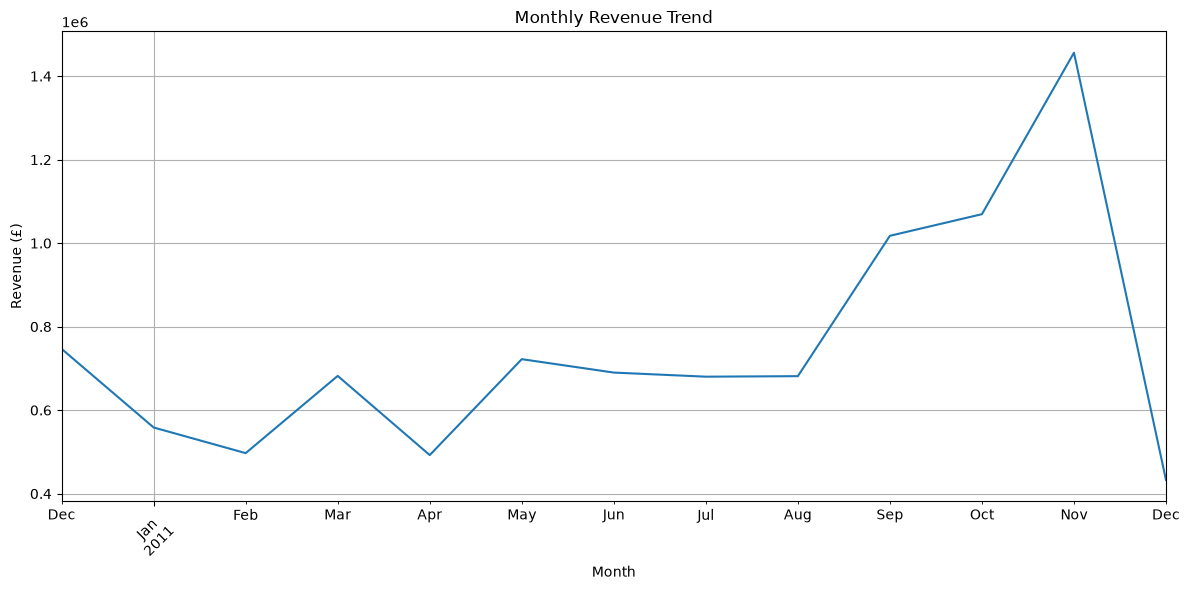

In [61]:
import matplotlib.pyplot as plt

monthly_revenue.plot(kind="line", figsize=(12, 6))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig("../visualizations/monthly_revenue.png", dpi=300)

plt.show()

## 8. Product Analysis

In [62]:
product_revenue = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_10_products = product_revenue.head(10)

top_10_products

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164459.49
WHITE HANGING HEART T-LIGHT HOLDER     99612.42
PARTY BUNTING                          98243.88
JUMBO BAG RED RETROSPOT                92175.79
RABBIT NIGHT LIGHT                     66661.63
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63715.24
ASSORTED COLOUR BIRD ORNAMENT          58792.42
CHILLI LIGHTS                          53746.66
Name: Revenue, dtype: float64

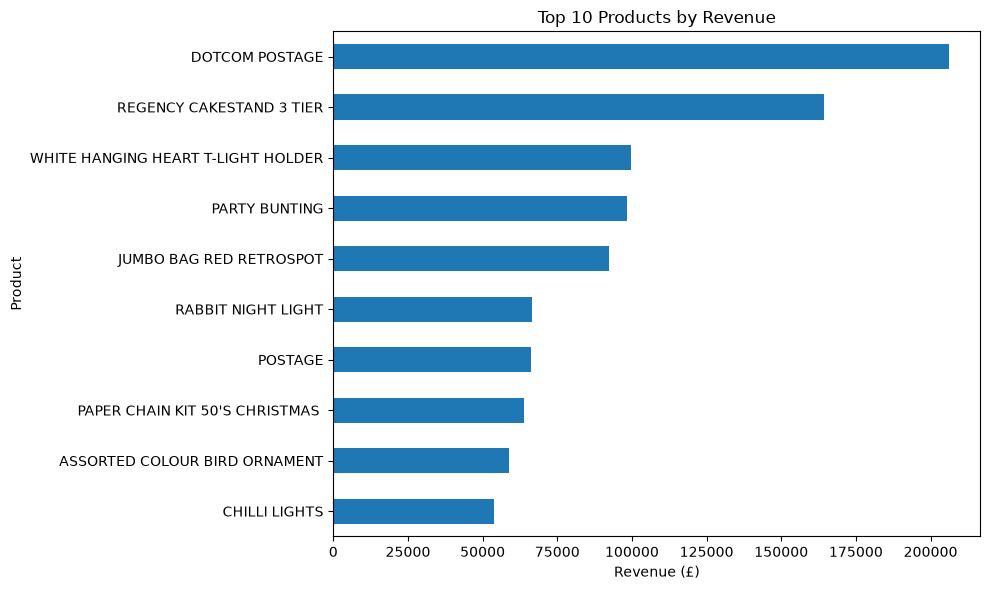

In [63]:
top_10_products.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig("../visualizations/top_10_products_revenue.png", dpi=300)

plt.show()

## 9. Country Analysis

In [64]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_10_countries = country_revenue.head(10)

top_10_countries

Country
United Kingdom    8167128.184
Netherlands        284661.540
EIRE               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Revenue, dtype: float64

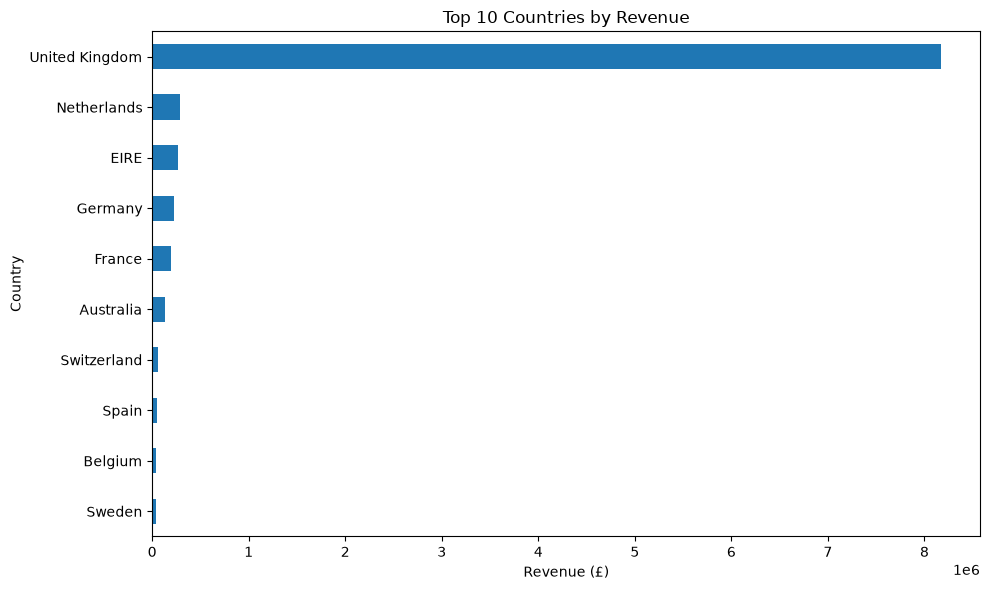

In [65]:
top_10_countries.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig("../visualizations/top_10_countries_revenue.png", dpi=300)

plt.show()

## 10. Customer Analysis

In [66]:
customer_revenue = (
    df.dropna(subset=["CustomerID"])
      .groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

top_10_customers = customer_revenue.head(10)

top_10_customers

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: Revenue, dtype: float64

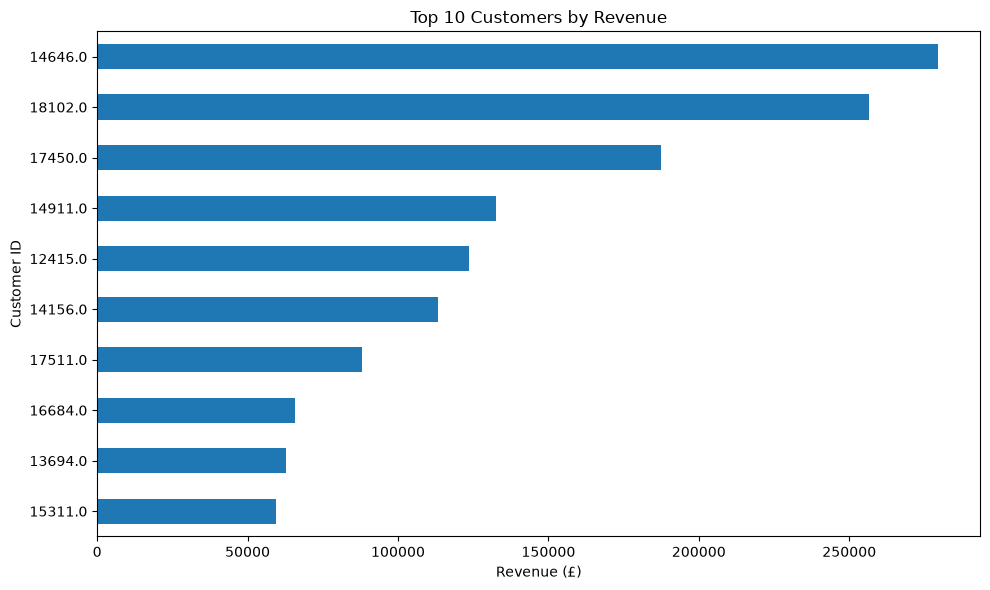

In [67]:
top_10_customers.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.tight_layout()

plt.savefig("../visualizations/top_10_customers_revenue.png", dpi=300)

plt.show()

## 11. Order Analysis

In [68]:
country_orders = (
    df.groupby("Country")["InvoiceNo"]
      .nunique()
      .sort_values(ascending=False)
)

top_10_country_orders = country_orders.head(10)

top_10_country_orders

Country
United Kingdom    23494
Germany             603
France              461
EIRE                360
Belgium             119
Spain               105
Netherlands         101
Switzerland          74
Portugal             71
Australia            69
Name: InvoiceNo, dtype: int64

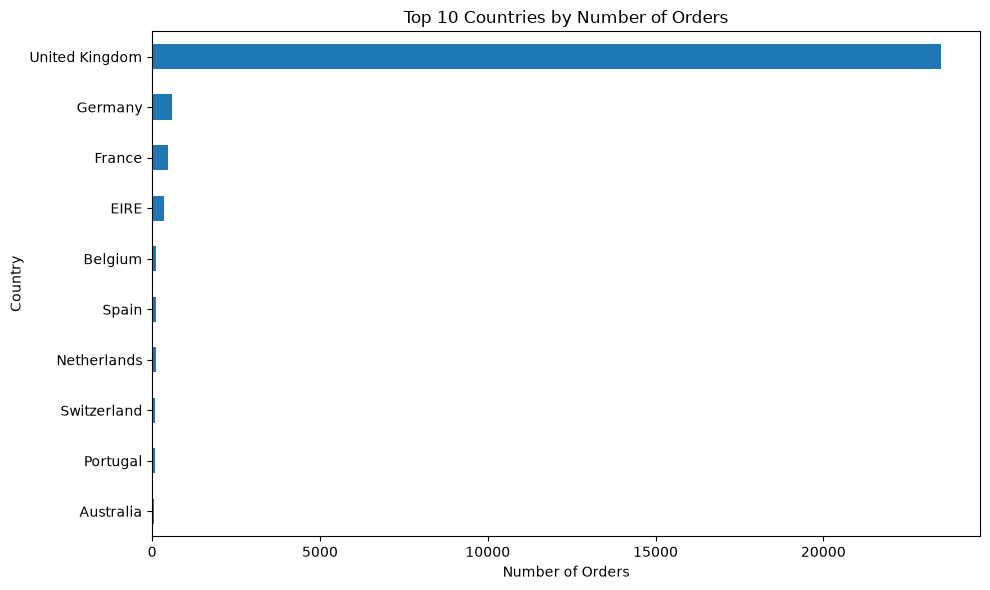

In [69]:
top_10_country_orders.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Countries by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig("../visualizations/top_10_countries_orders.png", dpi=300)

plt.show()

In [70]:
product_quantity = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

top_10_quantity = product_quantity.head(10)

top_10_quantity

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47260
POPCORN HOLDER                        36322
ASSORTED COLOUR BIRD ORNAMENT         36282
PACK OF 72 RETROSPOT CAKE CASES       36016
WHITE HANGING HEART T-LIGHT HOLDER    35298
RABBIT NIGHT LIGHT                    30631
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26299
PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: Quantity, dtype: int64

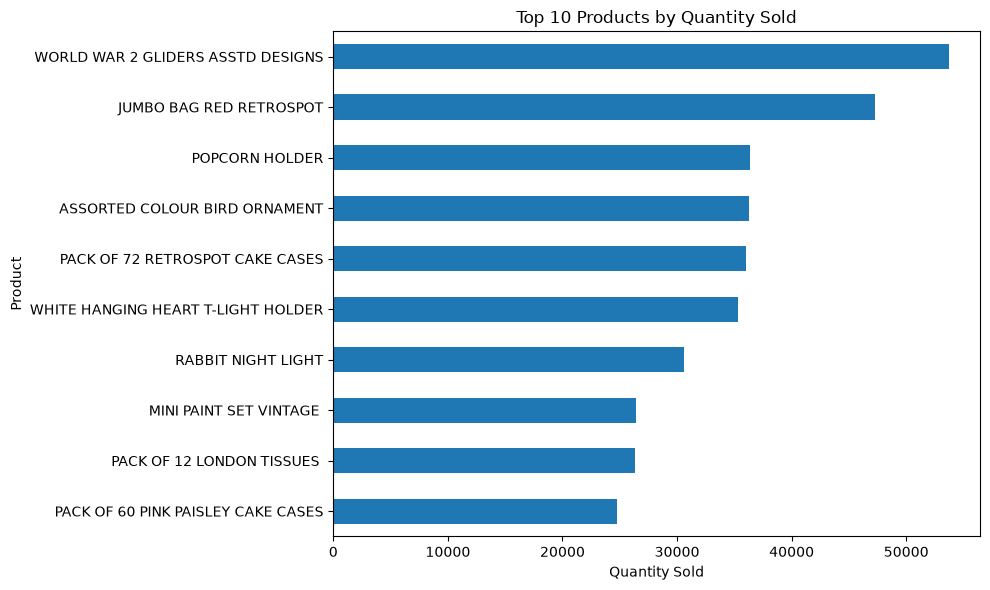

In [71]:
top_10_quantity.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig("../visualizations/top_10_products_quantity.png", dpi=300)

plt.show()

## 12. Cancellation Analysis

In [72]:
cancelled_orders = df[
    df["InvoiceNo"].astype(str).str.startswith("C")
]

cancelled_orders.shape

(9251, 10)

In [73]:
cancelled_order_count = cancelled_orders["InvoiceNo"].nunique()

print(f"Cancelled Orders: {cancelled_order_count:,}")

Cancelled Orders: 3,836


In [74]:
cancelled_revenue = cancelled_orders["Revenue"].sum()

print(f"Cancelled Transaction Value: £{cancelled_revenue:,.2f}")

Cancelled Transaction Value: £-893,979.73


In [75]:
cancellation_rate = (cancelled_order_count / total_orders) * 100

print(f"Cancellation Rate: {cancellation_rate:.2f}%")

Cancellation Rate: 14.81%


In [76]:
print("E-Commerce Sales Analysis Summary")
print("-" * 40)
print(f"Total Orders: {total_orders:,}")
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Average Order Value: £{aov:,.2f}")
print(f"Cancelled Orders: {cancelled_order_count:,}")
print(f"Cancellation Rate: {cancellation_rate:.2f}%")
print(f"Cancelled Transaction Value: £{cancelled_revenue:,.2f}")

E-Commerce Sales Analysis Summary
----------------------------------------
Total Orders: 25,900
Total Revenue: £9,726,006.95
Average Order Value: £375.52
Cancelled Orders: 3,836
Cancellation Rate: 14.81%
Cancelled Transaction Value: £-893,979.73


In [77]:
monthly_orders = (
    df.groupby("Month")["InvoiceNo"]
      .nunique()
      .sort_values(ascending=False)
)

monthly_orders.head(10)

Month
2011-11    3462
2011-10    2637
2011-09    2327
2011-05    2162
2010-12    2025
2011-06    2012
2011-03    1983
2011-07    1927
2011-04    1744
2011-08    1737
Freq: M, Name: InvoiceNo, dtype: int64

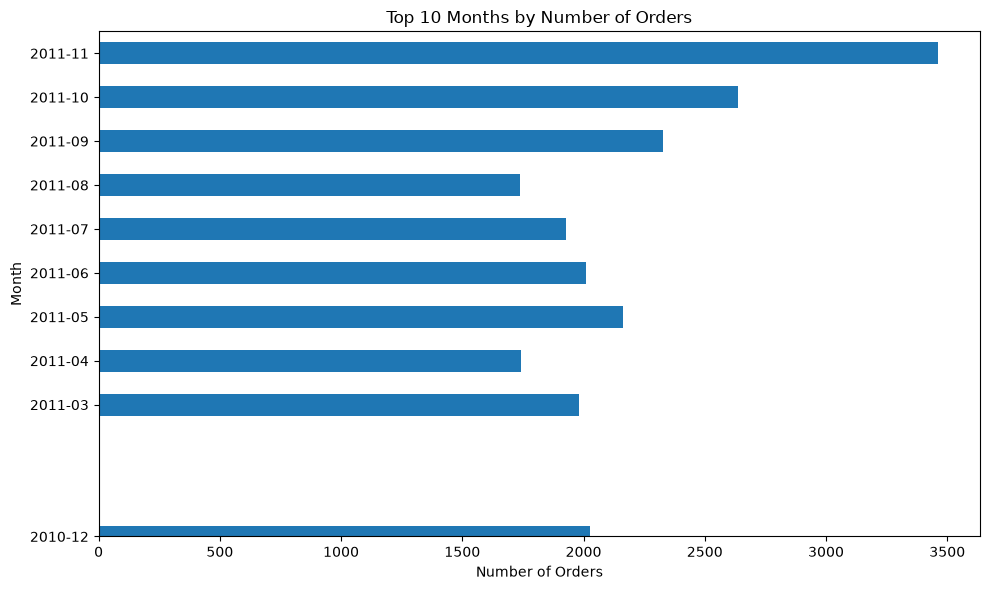

In [78]:
monthly_orders.sort_values().tail(10).plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Months by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Month")

plt.tight_layout()

plt.savefig("../visualizations/top_10_months_orders.png", dpi=300)

plt.show()

## 13. Product Performance Analysis

In [79]:
product_performance = (
    df.groupby("Description")
      .agg(
          Total_Quantity=("Quantity", "sum"),
          Total_Revenue=("Revenue", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
)

product_performance.head(10)

,Total_Quantity,Total_Revenue
Description,,
DOTCOM POSTAGE,707,206245.48
REGENCY CAKESTAND 3 TIER,13007,164459.49
WHITE HANGING HEART T-LIGHT HOLDER,35298,99612.42
PARTY BUNTING,18010,98243.88
JUMBO BAG RED RETROSPOT,47260,92175.79
RABBIT NIGHT LIGHT,30631,66661.63
POSTAGE,3003,66230.64
PAPER CHAIN KIT 50'S CHRISTMAS,18876,63715.24
ASSORTED COLOUR BIRD ORNAMENT,36282,58792.42


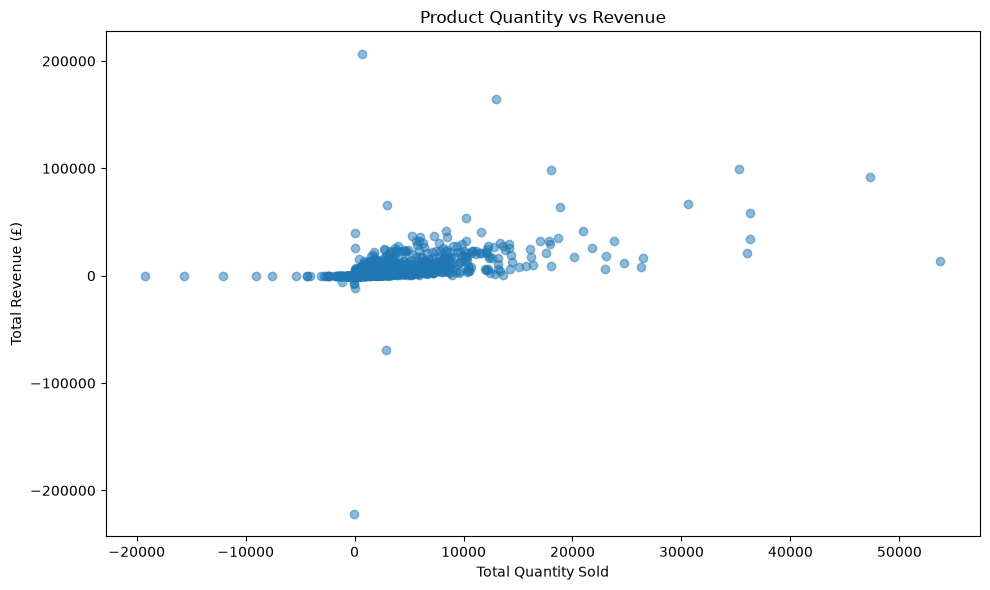

In [80]:
plt.figure(figsize=(10, 6))

plt.scatter(
    product_performance["Total_Quantity"],
    product_performance["Total_Revenue"],
    alpha=0.5
)

plt.title("Product Quantity vs Revenue")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Total Revenue (£)")

plt.tight_layout()

plt.savefig("../visualizations/product_quantity_vs_revenue.png", dpi=300)

plt.show()

In [81]:
print("KEY BUSINESS INSIGHTS")
print("=" * 50)

print(f"1. Total revenue generated: £{total_revenue:,.2f}")
print(f"2. Total orders recorded: {total_orders:,}")
print(f"3. Average order value: £{aov:,.2f}")
print(f"4. Cancelled orders: {cancelled_order_count:,}")
print(f"5. Cancellation rate: {cancellation_rate:.2f}%")

print("\nBusiness Analysis:")
print("- Revenue trends can be monitored using monthly sales analysis.")
print("- Top products contribute significantly to overall revenue.")
print("- Customer-level analysis helps identify high-value customers.")
print("- Country-level analysis highlights important geographic markets.")
print("- Product quantity and revenue analysis helps evaluate product performance.")
print("- Cancellation analysis can help businesses identify potential revenue losses.")

KEY BUSINESS INSIGHTS
1. Total revenue generated: £9,726,006.95
2. Total orders recorded: 25,900
3. Average order value: £375.52
4. Cancelled orders: 3,836
5. Cancellation rate: 14.81%

Business Analysis:
- Revenue trends can be monitored using monthly sales analysis.
- Top products contribute significantly to overall revenue.
- Customer-level analysis helps identify high-value customers.
- Country-level analysis highlights important geographic markets.
- Product quantity and revenue analysis helps evaluate product performance.
- Cancellation analysis can help businesses identify potential revenue losses.


In [82]:
completed_sales = df[
    ~df["InvoiceNo"].astype(str).str.startswith("C")
]

gross_revenue = completed_sales["Revenue"].sum()
completed_orders = completed_sales["InvoiceNo"].nunique()
completed_aov = gross_revenue / completed_orders

print("Completed Sales Analysis")
print("=" * 50)
print(f"Gross Revenue: £{gross_revenue:,.2f}")
print(f"Completed Orders: {completed_orders:,}")
print(f"Average Order Value: £{completed_aov:,.2f}")

Completed Sales Analysis
Gross Revenue: £10,619,986.68
Completed Orders: 22,064
Average Order Value: £481.33


## 14. Business Insights

The analysis provides useful insights into overall sales performance,
customer behavior, product performance, geographic markets, order trends,
and cancellations.

In [83]:
print("FINAL BUSINESS INSIGHTS")
print("=" * 60)

print(f"""
1. The business generated gross revenue of £{gross_revenue:,.2f}
   from {completed_orders:,} completed orders.

2. The average order value was £{completed_aov:,.2f},
   indicating the average value of a completed customer order.

3. {cancelled_order_count:,} orders were cancelled, representing
   {cancellation_rate:.2f}% of all recorded orders.

4. Cancelled transactions had a total negative value of
   £{abs(cancelled_revenue):,.2f}, highlighting the financial
   impact of cancellations and returns.

5. Monthly revenue analysis helps identify high-performing
   and low-performing periods.

6. Product revenue and quantity analysis helps identify
   products that contribute strongly to sales.

7. Customer revenue analysis helps identify high-value
   customers and potential customer retention opportunities.

8. Country-level analysis helps identify the most important
   geographic markets.

9. Comparing product quantity with revenue helps understand
   product performance and sales contribution.
""")

FINAL BUSINESS INSIGHTS

1. The business generated gross revenue of £10,619,986.68
   from 22,064 completed orders.

2. The average order value was £481.33,
   indicating the average value of a completed customer order.

3. 3,836 orders were cancelled, representing
   14.81% of all recorded orders.

4. Cancelled transactions had a total negative value of
   £893,979.73, highlighting the financial
   impact of cancellations and returns.

5. Monthly revenue analysis helps identify high-performing
   and low-performing periods.

6. Product revenue and quantity analysis helps identify
   products that contribute strongly to sales.

7. Customer revenue analysis helps identify high-value
   customers and potential customer retention opportunities.

8. Country-level analysis helps identify the most important
   geographic markets.

9. Comparing product quantity with revenue helps understand
   product performance and sales contribution.

